TOPIC: ANALYZING TRENDS AND PREDICTING CUSTOMER CHURN

Subject: Using CRM and Logistic Regression (CRM.LR)

In [1]:
# Import required libraries
from google.colab import files
from google.colab import drive
import pandas as pd  # For handling tabular data (DataFrames)
import numpy as np  # For numerical computations on arrays and matrices
import matplotlib.pyplot as plt  # For plotting charts and graphs
from sklearn.preprocessing import MinMaxScaler  # To normalize data to the range [0, 1]
from sklearn.cluster import KMeans  # For clustering data using the KMeans algorithm
from sklearn.metrics import silhouette_score  # To evaluate clustering quality
from sklearn.decomposition import PCA  # For dimensionality reduction
from sklearn.tree import DecisionTreeClassifier, plot_tree  # For decision tree classification and visualization
from sklearn.model_selection import train_test_split  # To split data into training and testing sets
from sklearn.metrics import classification_report, accuracy_score  # To generate precision, recall, F1-score, and accuracy metrics
from datetime import datetime  # For handling date and time data

In [2]:
# Mount Google Drive to access files
drive.mount('/content/drive')

Mounted at /content/drive


II. READ DATA

In [3]:
# Load dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/PythonDataAnalysis/shopping_trends_2.csv')

In [4]:
# Display the first 5 rows of the dataset
print(df.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

  Payment Method  Shipping Type Discount Applied Promo C

In [5]:
# Descriptive statistics for RFM columns before normalization
print("Descriptive statistics before normalization:")
print(df.describe())

Descriptive statistics before normalization:
       Customer ID          Age  Purchase Amount (USD)  Review Rating  \
count  3900.000000  3900.000000            3900.000000    3900.000000   
mean   1950.500000    44.068462              59.764359       3.749949   
std    1125.977353    15.207589              23.685392       0.716223   
min       1.000000    18.000000              20.000000       2.500000   
25%     975.750000    31.000000              39.000000       3.100000   
50%    1950.500000    44.000000              60.000000       3.700000   
75%    2925.250000    57.000000              81.000000       4.400000   
max    3900.000000    70.000000             100.000000       5.000000   

       Previous Purchases  
count         3900.000000  
mean            25.351538  
std             14.447125  
min              1.000000  
25%             13.000000  
50%             25.000000  
75%             38.000000  
max             50.000000  


III. FEATURE SELECTION

In [6]:

# Select columns relevant for RFM (Recency, Frequency, Monetary) analysis
rfm_columns = ["Customer ID", "Date of Purchase", "Previous Purchases", "Purchase Amount (USD)"]
df_rfm = df[rfm_columns].copy()

In [7]:
# Display the first 5 rows of the RFM dataset
print(df_rfm.head())

   Customer ID Date of Purchase  Previous Purchases  Purchase Amount (USD)
0            1       2025-02-26                  14                     53
1            2       2025-01-31                   2                     64
2            3       2024-05-29                  23                     73
3            4       2024-05-27                  49                     90
4            5       2024-04-23                  31                     49


IV. DATA PREPROCESSING

In [8]:
# Check for missing values in RFM columns
print("Checking for missing values in RFM columns:")
print(df_rfm.isnull().sum())

Checking for missing values in RFM columns:
Customer ID              0
Date of Purchase         0
Previous Purchases       0
Purchase Amount (USD)    0
dtype: int64


In [9]:
# Function to handle outliers using the Interquartile Range (IQR) method
def handle_outliers(df_rfm, column):
    Q1 = df_rfm[column].quantile(0.25)  # First quartile
    Q3 = df_rfm[column].quantile(0.75)  # Third quartile
    IQR = Q3 - Q1  # Interquartile range
    lower_bound = Q1 - 1.5 * IQR  # Lower bound for outliers
    upper_bound = Q3 + 1.5 * IQR  # Upper bound for outliers
    median = df_rfm[column].median()  # Median value for replacement
    # Replace outliers with the median
    df_rfm[column] = df_rfm[column].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
    return df_rfm

In [10]:
# Apply outlier handling to specified columns
for col in ["Previous Purchases", "Purchase Amount (USD)"]:
    df_rfm = handle_outliers(df_rfm, col)

In [11]:
# Display the first 5 rows after outlier handling
print(df_rfm.head())

   Customer ID Date of Purchase  Previous Purchases  Purchase Amount (USD)
0            1       2025-02-26                  14                     53
1            2       2025-01-31                   2                     64
2            3       2024-05-29                  23                     73
3            4       2024-05-27                  49                     90
4            5       2024-04-23                  31                     49


In [12]:
# Calculate RFM metrics
current_date = pd.to_datetime("2025-04-14")  # Reference date for Recency calculation
df_rfm["Date of Purchase"] = pd.to_datetime(df_rfm["Date of Purchase"])  # Convert to datetime
df_rfm["Recency"] = (current_date - df_rfm["Date of Purchase"]).dt.days  # Days since last purchase
df_rfm["Frequency"] = df_rfm["Previous Purchases"]  # Number of previous purchases
df_rfm["Monetary"] = df_rfm["Purchase Amount (USD)"]  # Total purchase amount

In [13]:
# Calculate RFM scores (segmenting into 5 quantiles)
df_rfm["R_score"] = pd.qcut(df_rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)  # Higher score for lower Recency
df_rfm["F_score"] = pd.qcut(df_rfm["Frequency"].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)  # Higher score for higher Frequency
df_rfm["M_score"] = pd.qcut(df_rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)  # Higher score for higher Monetary
df_rfm["RFM_score"] = df_rfm["R_score"].astype(str) + df_rfm["F_score"].astype(str) + df_rfm["M_score"].astype(str)  # Combine scores

In [14]:
# Display the first 5 rows with RFM scores
print(df_rfm.head())

   Customer ID Date of Purchase  Previous Purchases  Purchase Amount (USD)  \
0            1       2025-02-26                  14                     53   
1            2       2025-01-31                   2                     64   
2            3       2024-05-29                  23                     73   
3            4       2024-05-27                  49                     90   
4            5       2024-04-23                  31                     49   

   Recency  Frequency  Monetary  R_score  F_score  M_score RFM_score  
0       47         14        53        5        2        3       523  
1       73          2        64        5        1        3       513  
2      320         23        73        2        3        4       234  
3      322         49        90        2        5        5       255  
4      356         31        49        1        4        2       142  


In [15]:
# Normalize RFM features
numeric_columns = ["Recency", "Frequency", "Monetary"]
scaler = MinMaxScaler()
df_rfm[numeric_columns] = scaler.fit_transform(df_rfm[numeric_columns])  # Scale values to [0, 1]

In [16]:
# Display the first 5 rows after normalization
print(df_rfm.head())

   Customer ID Date of Purchase  Previous Purchases  Purchase Amount (USD)  \
0            1       2025-02-26                  14                     53   
1            2       2025-01-31                   2                     64   
2            3       2024-05-29                  23                     73   
3            4       2024-05-27                  49                     90   
4            5       2024-04-23                  31                     49   

    Recency  Frequency  Monetary  R_score  F_score  M_score RFM_score  
0  0.002755   0.265306    0.4125        5        2        3       523  
1  0.074380   0.020408    0.5500        5        1        3       513  
2  0.754821   0.448980    0.6625        2        3        4       234  
3  0.760331   0.979592    0.8750        2        5        5       255  
4  0.853994   0.612245    0.3625        1        4        2       142  


In [17]:
# Prepare data for KMeans clustering
rfm_features = df_rfm[["Recency", "Frequency", "Monetary"]].copy()

In [18]:
# Display the first 5 rows of clustering features
print(rfm_features.head())

    Recency  Frequency  Monetary
0  0.002755   0.265306    0.4125
1  0.074380   0.020408    0.5500
2  0.754821   0.448980    0.6625
3  0.760331   0.979592    0.8750
4  0.853994   0.612245    0.3625


In [19]:
# Display sample data with RFM scores
print("\nSample data with RFM scores:")
print(df_rfm[["Customer ID", "Recency", "Frequency", "Monetary", "R_score", "F_score", "M_score", "RFM_score"]].head(10))


Sample data with RFM scores:
   Customer ID   Recency  Frequency  Monetary  R_score  F_score  M_score  \
0            1  0.002755   0.265306    0.4125        5        2        3   
1            2  0.074380   0.020408    0.5500        5        1        3   
2            3  0.754821   0.448980    0.6625        2        3        4   
3            4  0.760331   0.979592    0.8750        2        5        5   
4            5  0.853994   0.612245    0.3625        1        4        2   
5            6  0.517906   0.265306    0.0000        3        2        1   
6            7  0.253444   0.979592    0.8125        4        5        5   
7            8  0.022039   0.367347    0.1750        5        2        1   
8            9  0.639118   0.142857    0.9625        2        1        5   
9           10  0.776860   0.061224    0.1375        2        1        1   

  RFM_score  
0       523  
1       513  
2       234  
3       255  
4       142  
5       321  
6       455  
7       521  
8      

In [20]:
# Elbow method to determine optimal number of clusters (K)
sse = []  # Sum of squared errors
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_features)
    sse.append(kmeans.inertia_)  # Store SSE for each K

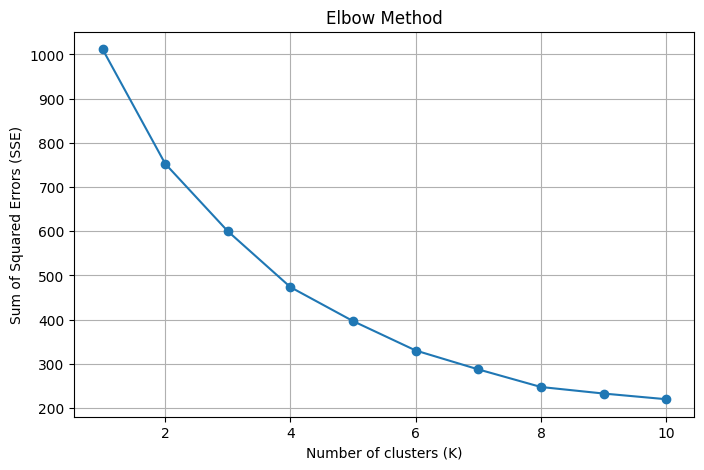

In [21]:
# Plot Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, sse, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [22]:
# Apply KMeans with optimal K=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=500)
df_rfm["Cluster"] = kmeans.fit_predict(rfm_features)  # Assign cluster labels

In [23]:
# Apply PCA for visualization
pca = PCA(n_components=3)
pca_components = pca.fit_transform(rfm_features)
df_rfm["PCA1"] = pca_components[:, 0]
df_rfm["PCA2"] = pca_components[:, 1]
df_rfm["PCA3"] = pca_components[:, 2]

In [24]:
# 3D Visualization using Plotly
import plotly.graph_objs as go
fig = go.Figure()
for cluster in df_rfm["Cluster"].unique():
    subset = df_rfm[df_rfm["Cluster"] == cluster]
    fig.add_trace(go.Scatter3d(
        x=subset["PCA1"],
        y=subset["PCA2"],
        z=subset["PCA3"],
        mode='markers',
        name=f'Cluster {cluster}',
        marker=dict(size=5, line=dict(width=0.5))
    ))
fig.update_layout(
    scene=dict(xaxis_title='PCA1', yaxis_title='PCA2', zaxis_title='PCA3'),
    title='Customer Clustering with KMeans + PCA (3D, K=4)',
    margin=dict(l=0, r=0, b=0, t=30)
)
fig.show()

In [25]:
# Evaluate clustering quality with Silhouette Score
score = silhouette_score(rfm_features, df_rfm["Cluster"])
print(f"Silhouette Score for K={optimal_k}: {score:.4f}")

Silhouette Score for K=4: 0.2706


In [26]:
# Summarize RFM metrics by cluster
cluster_summary = df_rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
print("\nAverage RFM by cluster:")
print(cluster_summary)


Average RFM by cluster:
          Recency  Frequency  Monetary
Cluster                               
0        0.437388   0.210386  0.735641
1        0.174829   0.539841  0.276951
2        0.501432   0.773559  0.752731
3        0.731634   0.468417  0.245944


# Cluster Interpretation:
- Cluster 0: High Recency, low Frequency and Monetary. Likely new customers with few transactions.
- Cluster 1: Low Recency, high Frequency, low Monetary. Frequent buyers with low spending.
- Cluster 2: Low Recency, high Frequency, high Monetary. Valuable customers with frequent and high-value transactions.
- Cluster 3: Very high Recency, low Frequency, low Monetary. Inactive customers who may need re-engagement strategies.

V. ANALYZING POTENTIAL CUSTOMERS WITH DECISION TREE

In [27]:
# Select the most valuable cluster (Cluster 2, based on high Frequency and Monetary)
target_cluster = df_rfm[df_rfm['Cluster'] == 2].copy()

In [28]:
# Create a synthetic target variable: Churn (1 = likely to churn, 0 = likely to stay)
target_cluster['Churn'] = ((target_cluster['Frequency'] < target_cluster['Frequency'].quantile(0.25)) |
                           (target_cluster['Recency'] > target_cluster['Recency'].quantile(0.75))).astype(int)

In [29]:
# Select features and split data into train/test sets
X = target_cluster[['Recency', 'Frequency', 'Monetary']]
y = target_cluster['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
# Train Decision Tree Classifier
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [31]:
# Evaluate model performance
y_pred = dtree.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       179
           1       1.00      1.00      1.00       107

    accuracy                           1.00       286
   macro avg       1.00      1.00      1.00       286
weighted avg       1.00      1.00      1.00       286



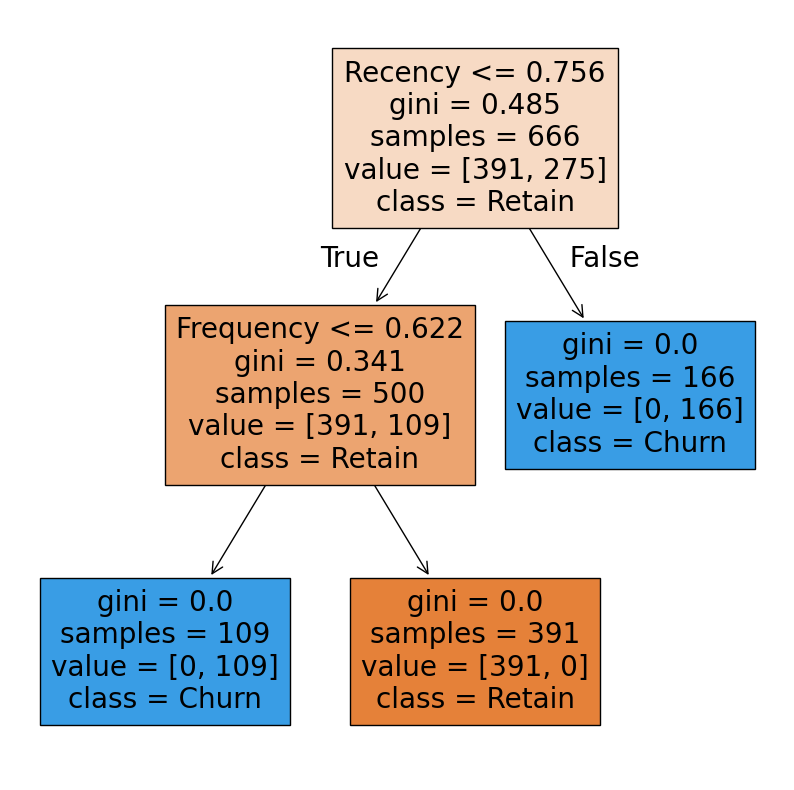

In [32]:
# Visualize the decision tree
plt.figure(figsize=(10, 10))
plot_tree(dtree, feature_names=['Recency', 'Frequency', 'Monetary'], class_names=['Retain', 'Churn'], filled=True)
plt.show()